# Crop Disease Prediction Using Deep Learning

## Project Objective

The objective of this project is to develop a Convolutional Neural Network (CNN) capable of identifying crop diseases from leaf images.

This system can help farmers detect diseases early and take preventive measures to improve crop yield.

Dataset Used: PlantVillage Dataset

Number of Classes: 38

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!unzip "/content/drive/MyDrive/plantvillage/plantvillagezipped.zip"

Streaming output truncated to the last 5000 lines.
  inflating: archive (2)/PlantVillage/val/Soybean___healthy/55ed6b1f-9baf-45d9-b4b4-4f19c7dc271a___RS_HL 7312.JPG  
  inflating: archive (2)/PlantVillage/val/Soybean___healthy/561d3eaf-4ff0-4580-9958-55494bf3a88b___RS_HL 6420.JPG  
  inflating: archive (2)/PlantVillage/val/Soybean___healthy/56486310-1cd5-4fb4-9fb8-01f60417f64f___RS_HL 6258.JPG  
  inflating: archive (2)/PlantVillage/val/Soybean___healthy/56a8722c-1acf-4f63-ba8c-66df35f47791___RS_HL 6311.JPG  
  inflating: archive (2)/PlantVillage/val/Soybean___healthy/5735f9f8-b5a4-42b4-b093-1e323323dfa2___RS_HL 3224.JPG  
  inflating: archive (2)/PlantVillage/val/Soybean___healthy/5755b898-21db-4c7f-8d5a-3401e8478192___RS_HL 4530.JPG  
  inflating: archive (2)/PlantVillage/val/Soybean___healthy/578f7dd6-55ae-4fb3-8f79-3ee460250ea7___RS_HL 2784.JPG  
  inflating: archive (2)/PlantVillage/val/Soybean___healthy/57afa416-2cfd-49d0-9674-e59b7955648c___RS_HL 3367.JPG  
  inflating: archive 

In [9]:
!ls "./archive (2)/PlantVillage"

train  val


In [10]:
train_dir = "/content/archive (2)/PlantVillage/train"
val_dir = "/content/archive (2)/PlantVillage/val"

In [11]:
import os

print("Train exists:", os.path.exists(train_dir))
print("Val exists:", os.path.exists(val_dir))

Train exists: True
Val exists: True


In [14]:
# Import required libraries for deep learning, image processing,
# numerical computation and visualization
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

## Data Preprocessing and Augmentation

In [15]:
# Apply data augmentation to improve model generalization
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
     rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load training and validation datasets
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
     shuffle=True
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.


## CNN Model Architecture

In [ ]:
# Build CNN model for crop disease classification
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile model using Adam optimizer and categorical crossentropy loss
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 426,214 (1.63 MB)

 Trainable params: 426,214 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 675s 496ms/step - accuracy: 0.7273 - loss: 0.8813 - val_accuracy: 0.7787 - val_loss: 0.6720
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 664s 489ms/step - accuracy: 0.7660 - loss: 0.7505 - val_accuracy: 0.7889 - val_loss: 0.6329
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 667s 491ms/step - accuracy: 0.7944 - loss: 0.6509 - val_accuracy: 0.8252 - val_loss: 0.5908
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 670s 493ms/step - accuracy: 0.8189 - loss: 0.5818 - val_accuracy: 0.8175 - val_loss: 0.5859
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 735s 541ms/step - accuracy: 0.8371 - loss: 0.5145 - val_accuracy: 0.9106 - val_loss: 0.2815


## Training Performance Visualization

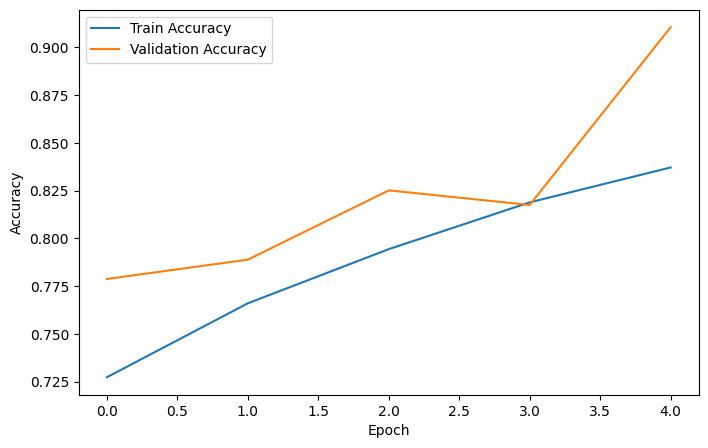

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

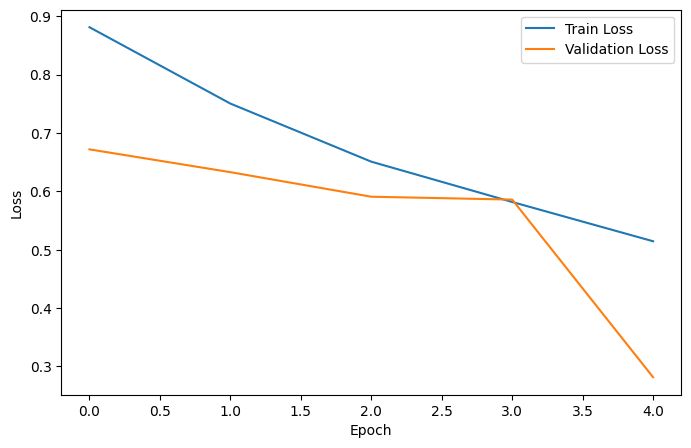

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Model Evaluation

The trained CNN model is evaluated using a Classification Report and Confusion Matrix.

The confusion matrix helps visualize correct and incorrect predictions across all disease classes.

In [ ]:
# Generate classification report on validation dataset

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Reset validation generator
val_data.reset()

# Predict validation images
predictions = model.predict(val_data)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = val_data.classes

# Print classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=list(val_data.class_indices.keys())
))

340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.90      0.75      0.81       126
                                 Apple___Black_rot       0.95      0.88      0.91       125
                          Apple___Cedar_apple_rust       0.92      0.87      0.90        55
                                   Apple___healthy       0.90      0.92      0.91       329
                               Blueberry___healthy       0.93      0.99      0.96       300
          Cherry_(including_sour)___Powdery_mildew       0.92      0.94      0.93       210
                 Cherry_(including_sour)___healthy       0.98      0.81      0.89       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.42      0.57       103
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       239
               Corn_(maize)___Northe

## Confusion Matrix

The confusion matrix provides a detailed visualization of model predictions.

A strong model will show most values concentrated along the diagonal, indicating correct classifications.

In [ ]:
# Generate confusion matrix for model evaluation

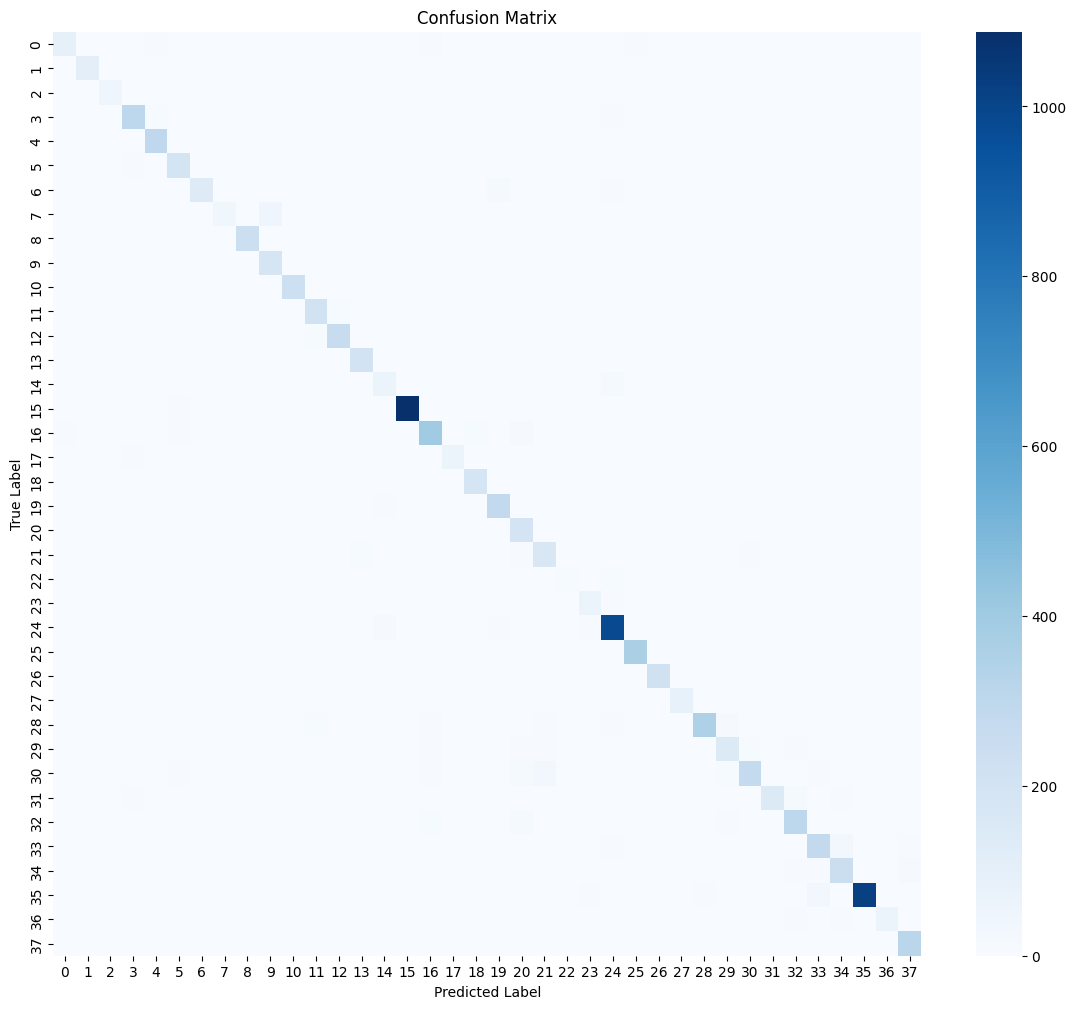

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

## Disease Prediction from Custom Images

The trained CNN model is tested on unseen crop leaf images uploaded by the user.

The model predicts:
- Disease Class
- Confidence Score
- Top 3 Most Probable Diseases

In [16]:
class_names = [None] * len(train_data.class_indices)

for name, index in train_data.class_indices.items():
    class_names[index] = name

print(class_names)
print("Number of classes:", len(class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

Saving Grape___Black_rot.png to Grape___Black_rot.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Top 3 Predictions:
Grape___Black_rot : 95.99%
Orange___Haunglongbing_(Citrus_greening) : 2.08%
Pepper,_bell___Bacterial_spot : 1.25%


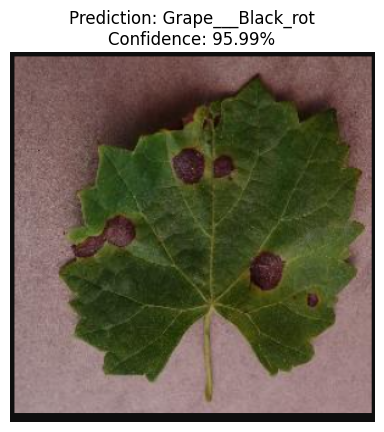

Predicted Disease: Grape___Black_rot
Confidence: 95.99 %


In [24]:
# Load custom image uploaded by user
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for img_name in uploaded.keys():
  img_path = img_name

  img = image.load_img(img_path, target_size=(img_size, img_size))
  img_array = image.img_to_array(img)
  img_array = img_array / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  # Generate prediction probabilities
  prediction = model.predict(img_array)
  # Get top 3 predictions
  top3 = np.argsort(prediction[0])[-3:][::-1]

  print("Top 3 Predictions:")
  for i in top3:
    print(f"{class_names[i]} : {prediction[0][i]*100:.2f}%")


  predicted_index = top3[0]
  confidence = prediction[0][predicted_index] * 100
  predicted_class = class_names[predicted_index]

  plt.imshow(image.load_img(img_path))
  plt.axis("off")
  plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
  plt.show()

  print("Predicted Disease:", predicted_class)
  print("Confidence:", round(confidence, 2), "%")



In [ ]:
# Save trained model for future use

model.save("crop_disease_model.keras")




## Manual Testing Results

To evaluate the trained CNN model, several unseen validation images from different crop categories were tested manually.




| Actual Class             | Predicted Class          | Confidence | Result    |
| ------------------------ | ------------------------ | ---------- | --------- |
| Apple___Apple_scab       | Apple___Apple_scab       | 69.98%     | Correct   |
| Tomato___Early_blight    | Tomato___Early_blight    | 52.81%     | Correct   |
| Soybean___healthy        | Soybean___healthy        | 99.99%     | Correct   |
| Strawberry___Leaf_scorch | Strawberry___Leaf_scorch | 99.95%     | Correct   |
| Grape___Black_rot        | Grape___Black_rot        | 95.99%     | Correct   |
| Potato___healthy         | Soybean___healthy        | 49.75%     | Incorrect |





The model correctly classified most manually tested validation images. Misclassification occurred mainly in classes with lower recall scores, such as Potato Healthy, which was also identified as a challenging class in the classification report.


## Project Results

The CNN model achieved strong performance on the PlantVillage dataset.

### Results Summary

- Number of Classes: 38
- Image Size: 224 × 224
- Deep Learning Model: CNN
- Data Augmentation: Applied
- Validation Accuracy: 91.06%
- Validation Loss: 0.2815
- Weighted Precision: 91%
- Weighted Recall: 91%
- Weighted F1-Score: 91%

The model successfully identifies crop diseases from leaf images across 38 different classes. The trained CNN achieved 91.06% validation accuracy and demonstrated strong performance on unseen validation images. The model correctly classified diseases such as Apple Scab, Tomato Early Blight, Grape Black Rot, Strawberry Leaf Scorch, and Soybean Healthy with high confidence scores.

Limitations:
- Model performs best on PlantVillage-style images.
- Real-world field images with complex backgrounds may reduce accuracy.
- Some classes such as Potato_healthy have lower recall.

Future Enhancements:
- Use Transfer Learning (MobileNetV2, EfficientNet).
- Deploy as a web application using Streamlit.
- Support real-time mobile image capture.
- Expand dataset with real-world farm images.